# Tweets Dataset - Exploratory Data Analysis (EDA)

Exploratory analysis of the raw Twitter/X dataset across stock tickers.

**Data source**: `Raw_Data/tweets/` directory  
**Columns**: `ticker, search_date, body, post_date, replies, retweets, likes`  
**Period**: 10 October 2023 - 10 October 2025

## 1. Imports and Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Resolve data directory
BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "Raw_Data/tweets").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = BASE_DIR / "Raw_Data/tweets"
print(f"Data directory: {INPUT_DIR}")

# Load all tweet CSVs into a single DataFrame
all_files = sorted(INPUT_DIR.glob("tweets_*.csv"))
print(f"Found {len(all_files)} tweet CSV files")

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    dfs.append(df)

tweets = pd.concat(dfs, ignore_index=True)
tweets["post_date"] = pd.to_datetime(tweets["post_date"], errors="coerce")
tweets["search_date"] = pd.to_datetime(tweets["search_date"], errors="coerce")
tweets["date_only"] = tweets["post_date"].dt.date

print(f"\nTotal tweets loaded: {len(tweets):,}")
tweets.head()

Data directory: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Raw_Data\tweets
Found 20 tweet CSV files

Total tweets loaded: 436,588


,ticker,search_date,body,post_date,replies,retweets,likes,date_only
0,AAPL,2023-10-10,Unusual Whales OI updates have been finished H...,2023-10-10 11:09:19+00:00,0,0,1.0,2023-10-10
1,AAPL,2023-10-10,"$WSM, $TER, $AAPL, $HDSN, $LRCX, $BSM, $MANH a...",2023-10-10 12:00:00+00:00,0,0,0.0,2023-10-10
2,AAPL,2023-10-10,$AAPL is moving higher,2023-10-10 12:38:13+00:00,0,0,0.0,2023-10-10
3,AAPL,2023-10-10,Key chip suppliers for iPhone 15 $AAPL $AVGO $...,2023-10-10 14:16:00+00:00,0,0,4.0,2023-10-10
4,AAPL,2023-10-10,Hard to catch $TSLA. In the picture you also s...,2023-10-10 14:52:44+00:00,0,0,0.0,2023-10-10


## 2. Dataset Overview

In [3]:
print("Shape:", tweets.shape)
print("\nColumn dtypes:")
print(tweets.dtypes)

print("\nMissing values:")
missing = tweets.isnull().sum()
missing_pct = (missing / len(tweets) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0])

print("\nDuplicate rows:", tweets.duplicated().sum())

Shape: (436588, 8)

Column dtypes:
ticker                         str
search_date         datetime64[us]
body                           str
post_date      datetime64[us, UTC]
replies                      int64
retweets                     int64
likes                      float64
date_only                   object
dtype: object

Missing values:


,Missing Count,Missing %



Duplicate rows: 0


In [4]:
tweets.describe(include="all")

,ticker,search_date,body,post_date,replies,retweets,likes,date_only
count,436588,436588,436588,436588,436588.000000,436588.000000,436588.000000,436588
unique,20,NaN,378513,NaN,NaN,NaN,NaN,816
top,TSLA,NaN,$TSLA,NaN,NaN,NaN,NaN,2025-12-09
freq,65182,NaN,1331,NaN,NaN,NaN,NaN,4108
mean,NaN,2024-12-15 19:47:32.868150,NaN,2024-12-17 12:01:43.934034+00:00,3.964720,5.124383,42.465049,NaN
min,NaN,2023-10-10 00:00:00,NaN,2023-10-10 00:05:56+00:00,0.000000,0.000000,0.000000,NaN
25%,NaN,2024-05-05 00:00:00,NaN,2024-05-06 19:46:25.250000+00:00,0.000000,0.000000,0.000000,NaN
50%,NaN,2024-12-23 00:00:00,NaN,2024-12-25 10:15:14+00:00,0.000000,0.000000,2.000000,NaN
75%,NaN,2025-08-03 00:00:00,NaN,2025-08-04 21:47:00.750000+00:00,2.000000,1.000000,10.000000,NaN
max,NaN,2025-12-31 00:00:00,NaN,2026-02-11 14:34:13+00:00,3600.000000,10000.000000,163000.000000,NaN


## 3. Tweet Counts by Ticker

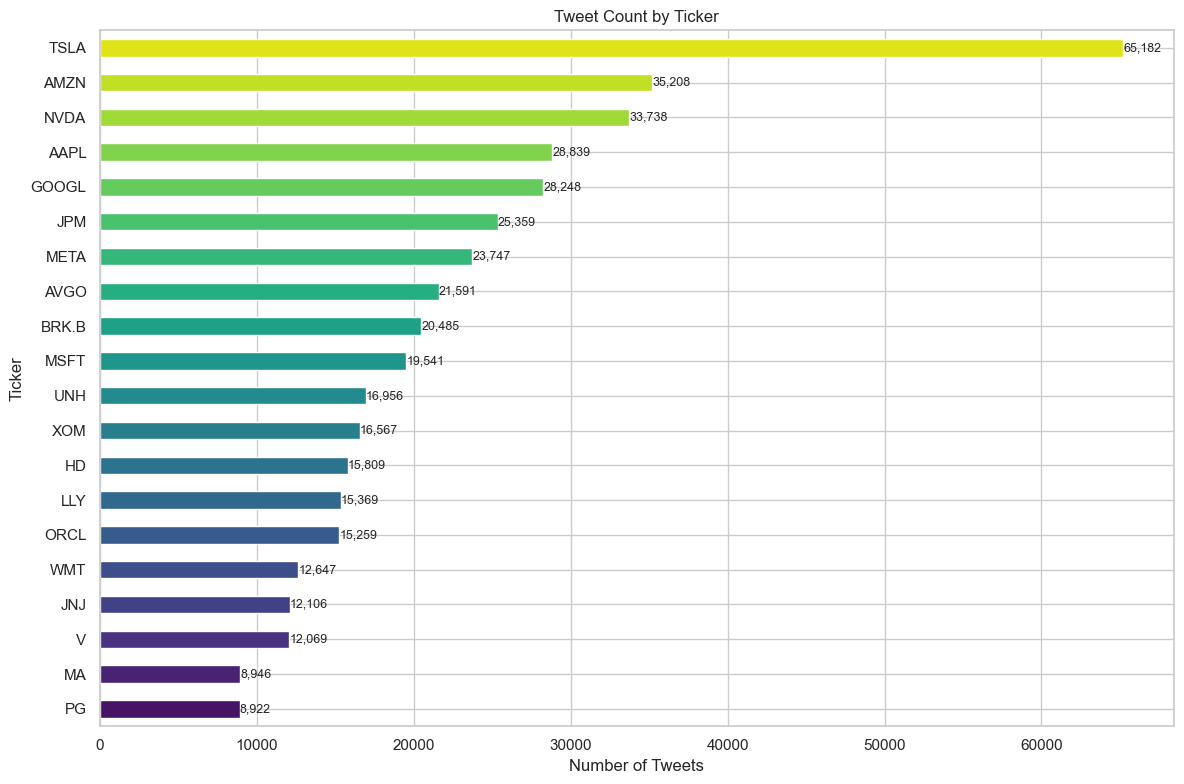


Mean: 21,829
Median: 18,248
Standard Deviation: 12,759


In [5]:
ticker_counts = tweets["ticker"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ticker_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(ticker_counts)))
ax.set_xlabel("Number of Tweets")
ax.set_ylabel("Ticker")
ax.set_title("Tweet Count by Ticker")

for i, v in enumerate(ticker_counts):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_by_ticker.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nMean: {ticker_counts.mean():,.0f}")
print(f"Median: {ticker_counts.median():,.0f}")
print(f"Standard Deviation: {ticker_counts.std():,.0f}")

## 4. Date Range and Temporal Coverage

In [6]:
# Date range per ticker
date_ranges = tweets.groupby("ticker")["post_date"].agg(["min", "max", "count"]).sort_values("count", ascending=False)
date_ranges.columns = ["Earliest", "Latest", "Count"]
display(date_ranges)

,Earliest,Latest,Count
ticker,,,
TSLA,2023-10-10 17:05:39+00:00,2026-02-11 14:34:13+00:00,65182
AMZN,2023-10-10 12:09:45+00:00,2025-12-31 23:56:32+00:00,35208
NVDA,2023-10-10 02:12:27+00:00,2025-12-31 23:51:08+00:00,33738
AAPL,2023-10-10 11:09:19+00:00,2025-12-31 23:11:00+00:00,28839
GOOGL,2023-10-10 01:14:27+00:00,2025-12-31 22:50:47+00:00,28248
JPM,2023-10-10 23:06:10+00:00,2025-12-21 22:27:05+00:00,25359
META,2023-10-10 11:12:40+00:00,2025-12-30 23:58:00+00:00,23747
AVGO,2023-10-10 00:41:04+00:00,2025-12-31 23:45:18+00:00,21591
BRK.B,2023-10-10 00:05:56+00:00,2025-12-31 23:59:10+00:00,20485


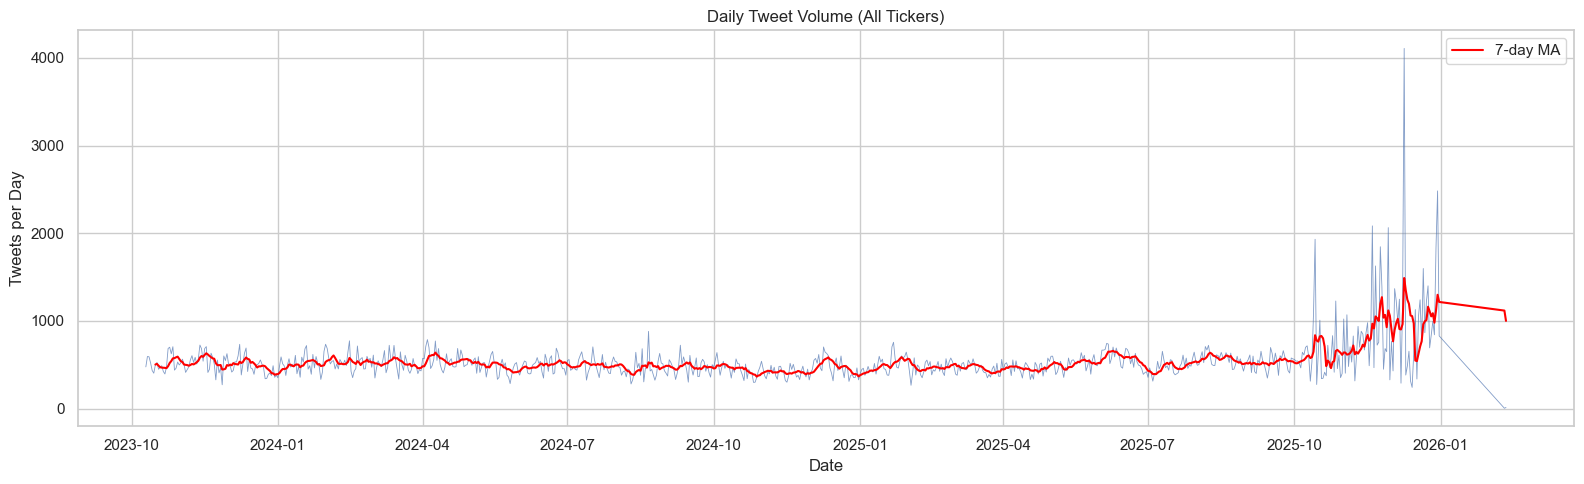

Average tweets per day: 535.0
Max tweets in a day: 4108 (2025-12-09)
Min tweets in a day: 4 (2026-02-10)


In [7]:
# Daily tweet volume across all tickers
daily_counts = tweets.groupby("date_only").size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.6, alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Tweets per Day")
ax.set_title("Daily Tweet Volume (All Tickers)")

# Add 7-day rolling average
rolling = daily_counts.rolling(7).mean()
ax.plot(rolling.index, rolling.values, color="red", linewidth=1.5, label="7-day MA")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Average tweets per day: {daily_counts.mean():.1f}")
print(f"Max tweets in a day: {daily_counts.max()} ({daily_counts.idxmax()})")
print(f"Min tweets in a day: {daily_counts.min()} ({daily_counts.idxmin()})")

C:\Users\Alasteir\AppData\Local\Temp\ipykernel_32744\1287609782.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["year_month"] = tweets["post_date"].dt.to_period("M")


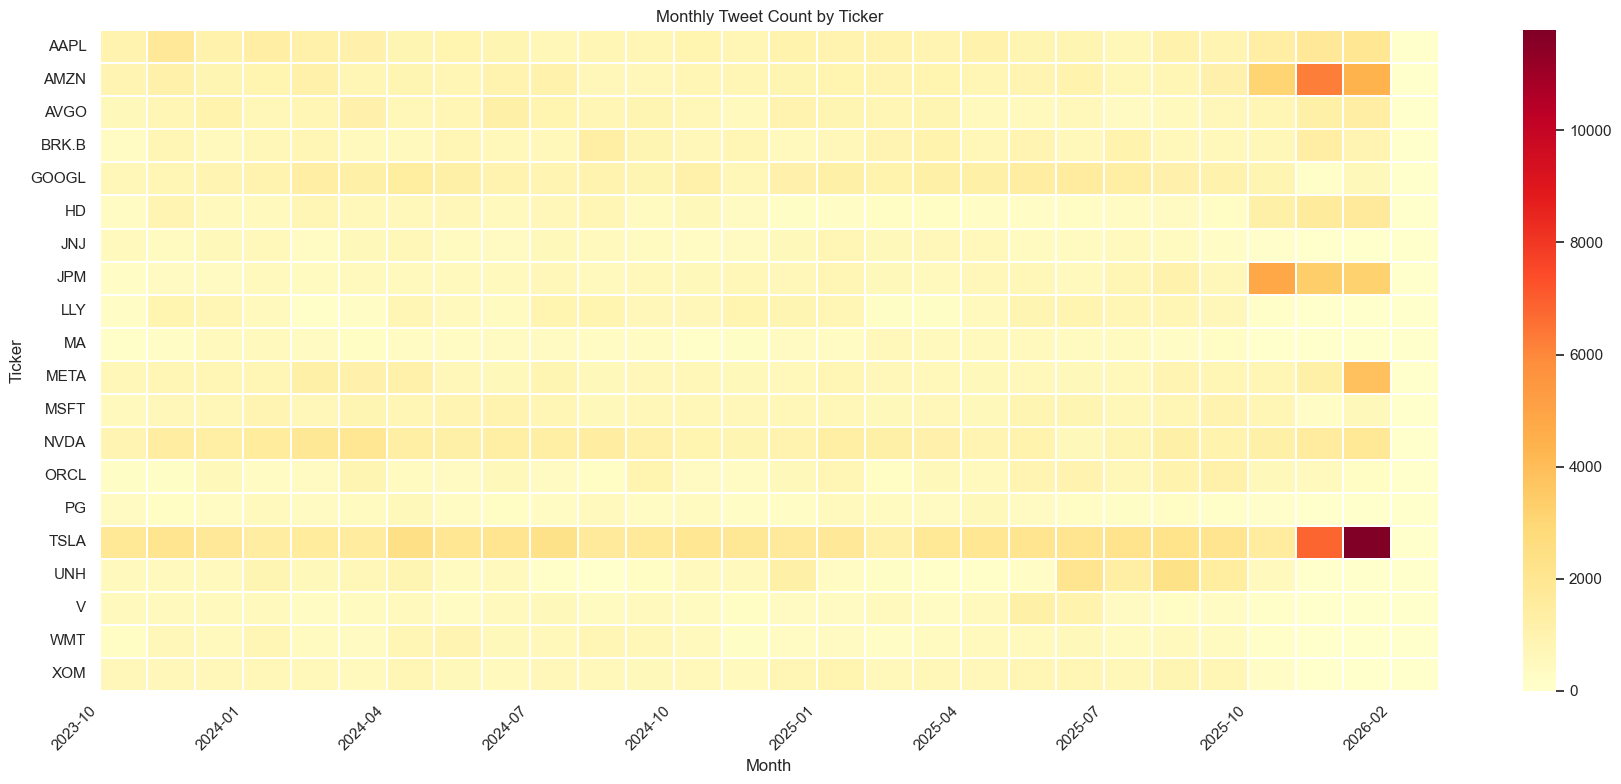

In [8]:
# Monthly tweet volume by ticker (heatmap)
tweets["year_month"] = tweets["post_date"].dt.to_period("M")
monthly_ticker = tweets.groupby(["year_month", "ticker"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(monthly_ticker.T, cmap="YlOrRd", ax=ax, linewidths=0.3)
ax.set_title("Monthly Tweet Count by Ticker")
ax.set_xlabel("Month")
ax.set_ylabel("Ticker")

# Reduce x-tick clutter
tick_positions = range(0, len(monthly_ticker.index), 3)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(monthly_ticker.index[i]) for i in tick_positions], rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 5. Engagement Metrics Analysis

In [9]:
# Engagement metrics summary
engagement_cols = ["replies", "retweets", "likes"]
engagement_stats = tweets[engagement_cols].describe()
display(engagement_stats)

# Total engagement
tweets["total_engagement"] = tweets["replies"] + tweets["retweets"] + tweets["likes"]
print(f"\nTotal engagement across all tweets: {tweets['total_engagement'].sum():,}")
print(f"Average engagement per tweet: {tweets['total_engagement'].mean():.1f}")

,replies,retweets,likes
count,436588.000000,436588.000000,436588.000000
mean,3.964720,5.124383,42.465049
std,24.094224,56.809587,537.452001
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,2.000000
75%,2.000000,1.000000,10.000000
max,3600.000000,10000.000000,163000.000000



Total engagement across all tweets: 22,507,924.0
Average engagement per tweet: 51.6


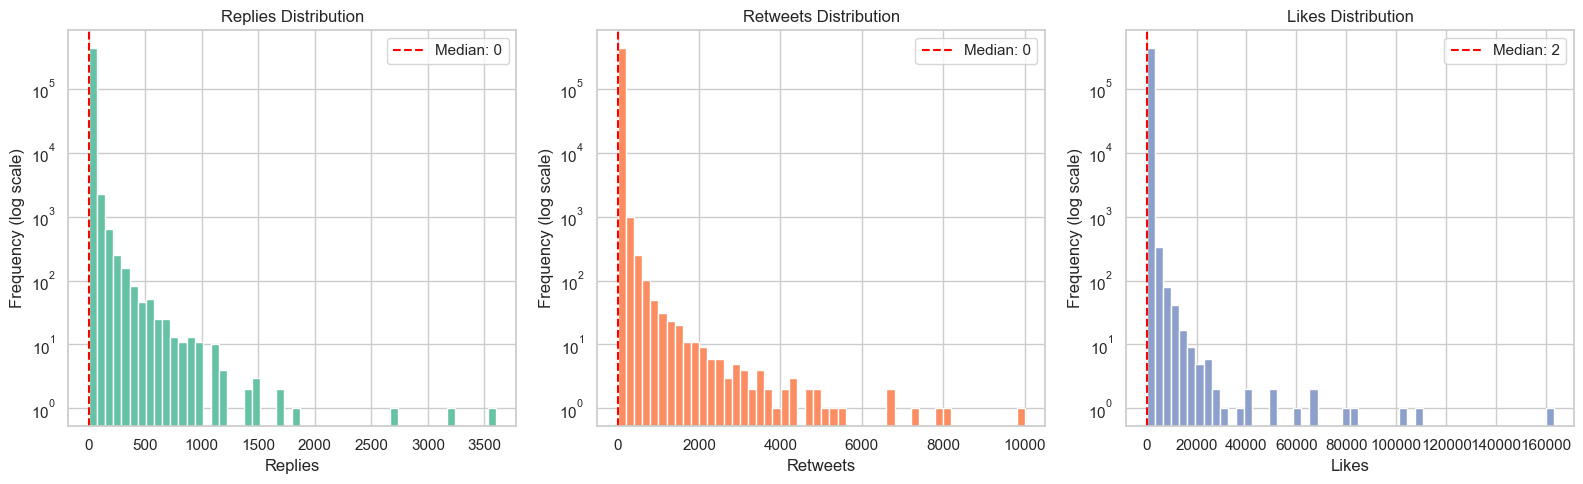

In [10]:
# Distribution of engagement metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(engagement_cols):
    # Use log scale for better visualization (add 1 to handle zeros)
    data = tweets[col] + 1
    axes[i].hist(data, bins=50, color=sns.color_palette("Set2")[i], edgecolor="white", log=True)
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Frequency (log scale)")
    axes[i].set_title(f"{col.capitalize()} Distribution")
    axes[i].axvline(tweets[col].median() + 1, color="red", linestyle="--", label=f"Median: {tweets[col].median():.0f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

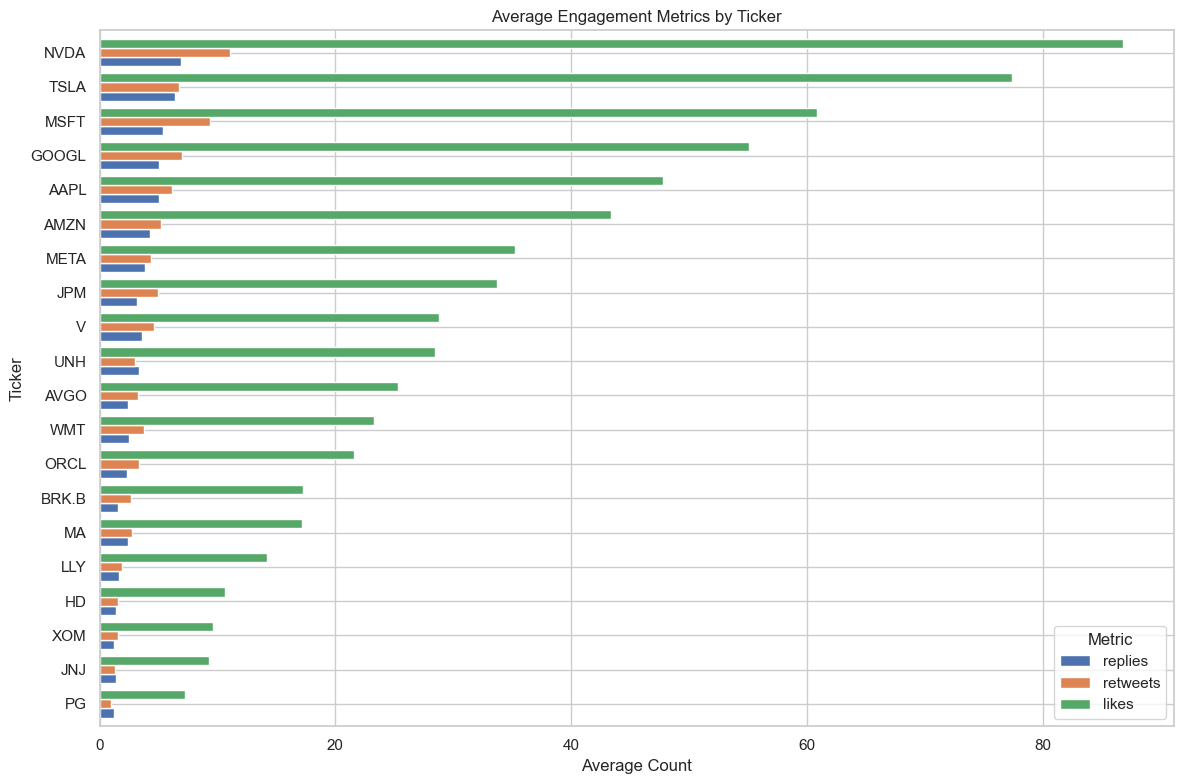

In [11]:
# Average engagement by ticker
engagement_by_ticker = tweets.groupby("ticker")[engagement_cols].mean().sort_values("likes", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
engagement_by_ticker.plot(kind="barh", ax=ax, width=0.8)
ax.set_xlabel("Average Count")
ax.set_ylabel("Ticker")
ax.set_title("Average Engagement Metrics by Ticker")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

In [12]:
# Top 10 most engaged tweets
top_tweets = tweets.nlargest(10, "total_engagement")[["ticker", "body", "likes", "retweets", "replies", "total_engagement", "post_date"]]
print("Top 10 Most Engaged Tweets:")
for idx, row in top_tweets.iterrows():
    print(f"\n[{row['ticker']}] {row['total_engagement']:,} engagement ({row['likes']:,} likes, {row['retweets']:,} RT, {row['replies']:,} replies)")
    print(f"  {row['body'][:150]}..." if len(str(row['body'])) > 150 else f"  {row['body']}")

Top 10 Most Engaged Tweets:

[TSLA] 171,374.0 engagement (163,000.0 likes, 7,900 RT, 474 replies)
  Knew a dude who emailed the IT guy directly instead of submitting a ticket and they blew his shit smoove off

[TSLA] 115,200.0 engagement (109,000.0 likes, 4,800 RT, 1,400 replies)
  THIS ERIKA KIRK BITCH REMOVED THEIR WEDDING PHOTO FROM CHARLIE’S BOOKSHELF.

[TSLA] 110,151.0 engagement (102,000.0 likes, 8,000 RT, 151 replies)
  Now is a good time to remind you that Harvey Levin, the founder of TMZ, was/is good friends with Jeffrey Epstein.

[TSLA] 85,682.0 engagement (82,000.0 likes, 3,100 RT, 582 replies)
  Yikes

[TSLA] 82,988.0 engagement (79,000.0 likes, 3,300 RT, 688 replies)
  She’s not wearing her cross

[TSLA] 76,486.0 engagement (66,000.0 likes, 10,000 RT, 486 replies)
  I’ll never understand how Oprah and Jay-Z can walk out off all these controversies freely like nothing happened

[TSLA] 69,371.0 engagement (68,000.0 likes, 1,300 RT, 71 replies)
  TIMELINE CLEANSE

[TSLA] 61,8

## 6. Tweet Body Length Analysis

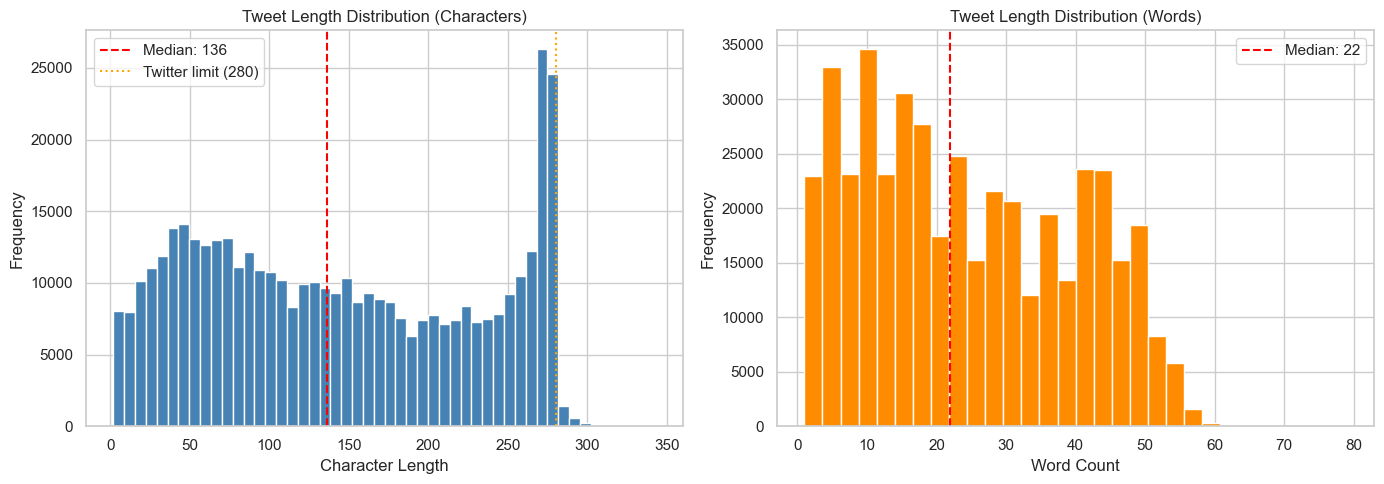

Tweet character length - Mean: 144.1, Median: 136, Std: 86.7
Tweet word count       - Mean: 24.3, Median: 22, Std: 15.1


In [13]:
tweets["body_len"] = tweets["body"].astype(str).str.len()
tweets["body_word_count"] = tweets["body"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tweets["body_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Tweet Length Distribution (Characters)")
axes[0].axvline(tweets["body_len"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_len'].median():.0f}")
axes[0].axvline(280, color="orange", linestyle=":", label="Twitter limit (280)")
axes[0].legend()

axes[1].hist(tweets["body_word_count"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Tweet Length Distribution (Words)")
axes[1].axvline(tweets["body_word_count"].median(), color="red", linestyle="--", label=f"Median: {tweets['body_word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_length.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Tweet character length - Mean: {tweets['body_len'].mean():.1f}, Median: {tweets['body_len'].median():.0f}, Std: {tweets['body_len'].std():.1f}")
print(f"Tweet word count       - Mean: {tweets['body_word_count'].mean():.1f}, Median: {tweets['body_word_count'].median():.0f}, Std: {tweets['body_word_count'].std():.1f}")

## 7. Day-of-Week and Hour Distribution

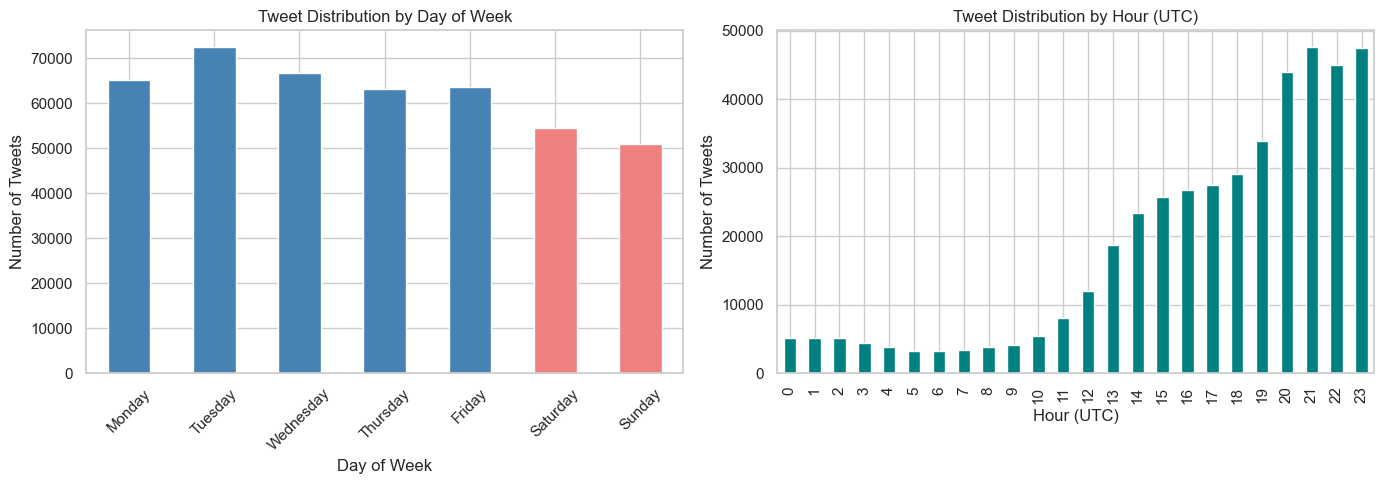

Weekday tweets: 331,136 (75.8%)
Weekend tweets: 105,452 (24.2%)


In [14]:
tweets["day_of_week"] = tweets["post_date"].dt.day_name()
tweets["hour"] = tweets["post_date"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = tweets["day_of_week"].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
dow_counts.plot(kind="bar", ax=axes[0], color=["steelblue"]*5 + ["lightcoral"]*2)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Tweet Distribution by Day of Week")
axes[0].tick_params(axis="x", rotation=45)

# Hour of day
hour_counts = tweets["hour"].value_counts().sort_index()
hour_counts.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_xlabel("Hour (UTC)")
axes[1].set_ylabel("Number of Tweets")
axes[1].set_title("Tweet Distribution by Hour (UTC)")

plt.tight_layout()
plt.show()

weekday = dow_counts[:5].sum()
weekend = dow_counts[5:].sum()
print(f"Weekday tweets: {weekday:,} ({weekday/len(tweets)*100:.1f}%)")
print(f"Weekend tweets: {weekend:,} ({weekend/len(tweets)*100:.1f}%)")

## 8. Duplicate and Data Quality Analysis

In [15]:
# Check for duplicate tweet bodies
dup_bodies = tweets["body"].duplicated().sum()
dup_full = tweets.duplicated().sum()

print(f"Duplicate tweet bodies (Same text, different Ticker): {dup_bodies:,} ({dup_bodies/len(tweets)*100:.1f}%)")
print(f"Fully duplicate rows (Summation of duplicates per ticker): {dup_full:,} ({dup_full/len(tweets)*100:.1f}%)")

# Duplicate body counts per ticker (per file)
print("\nDuplicate bodies per ticker:")
dup_per_ticker = tweets.groupby("ticker")["body"].apply(lambda x: x.duplicated().sum())
dup_total_per_ticker = tweets.groupby("ticker").size()
dup_pct = (dup_per_ticker / dup_total_per_ticker * 100).round(2)
dup_df = pd.DataFrame({"Duplicate Bodies": dup_per_ticker, "Total": dup_total_per_ticker, "Duplicate %": dup_pct})
dup_df = dup_df.sort_values("Duplicate Bodies", ascending=False)
display(dup_df)

# Tweets appearing across multiple tickers
body_ticker_count = tweets.groupby("body")["ticker"].nunique()
cross_ticker = body_ticker_count[body_ticker_count > 1]
print(f"\nTweets mentioning multiple tickers: {len(cross_ticker):,}")

if len(cross_ticker) > 0:
    print("\nSample cross-ticker tweets:")
    for body in cross_ticker.sort_values(ascending=False).head(5).index:
        tickers = tweets[tweets["body"] == body]["ticker"].unique()
        print(f"  [{', '.join(tickers)}] {str(body)[:100]}")

Duplicate tweet bodies (Same text, different Ticker): 58,075 (13.3%)
Fully duplicate rows (Summation of duplicates per ticker): 0 (0.0%)

Duplicate bodies per ticker:


,Duplicate Bodies,Total,Duplicate %
ticker,,,
TSLA,7684,65182,11.79
JPM,3158,25359,12.45
AMZN,2857,35208,8.11
BRK.B,2807,20485,13.70
HD,2128,15809,13.46
MA,2109,8946,23.57
XOM,1895,16567,11.44
AVGO,1689,21591,7.82
PG,1629,8922,18.26



Tweets mentioning multiple tickers: 16,444

Sample cross-ticker tweets:
  [AAPL, BRK.B, MSFT, NVDA, TSLA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $GOOGL $LLY $AVGO $GOOG $UNH
  [AAPL, BRK.B, JPM, MSFT, NVDA, XOM] Top 25 Stocks Institutional Investors Own $MSFT $AAPL $NVDA $AMZN $META $LLY $GOOGL $AVGO $GOOG $UNH
  [AAPL, AMZN, BRK.B, JPM, MSFT, XOM] What Stocks Do Institutional Investors Own? I give you the Top 25 $MSFT $AAPL $AMZN $NVDA $GOOGL $AV
  [AAPL, BRK.B, JPM, MSFT, TSLA, XOM] 【時価総額上位銘柄トレンド】 $AAPL $MSFT $GOOG $AMZN $TSLA $BRK.B $META $JNJ $T $NVDA $KO $XOM $WMT $PG $JPM $V $M
  [AMZN, BRK.B, UNH, WMT, XOM] The Largest U.S. Companies by Revenue in 2025: $WMT $AMZN $UNH $AAPL $CVS $BRK.B $GOOGL $XOM $MCK $C


In [16]:
# Check for empty or very short tweets
empty_tweets = tweets[tweets["body"].isna() | (tweets["body"] == "")]
short_tweets = tweets[tweets["body_len"] < 10]

print(f"Empty tweets: {len(empty_tweets):,}")
print(f"Very short tweets (<10 chars): {len(short_tweets):,}")

if len(short_tweets) > 0:
    print("\nSample short tweets:")
    for _, row in short_tweets.head(5).iterrows():
        print(f"  [{row['ticker']}] '{row['body']}'")

Empty tweets: 0
Very short tweets (<10 chars): 8,850

Sample short tweets:
  [AAPL] '$AAPL'
  [AAPL] '$AAPL'
  [AAPL] '$AAPL'
  [AAPL] '$AAPL 애플'
  [AAPL] '$AAPL'


## 8.5 Language Breakdown

Languages detected: 66

Top 10 languages:


,Count,%
language,,
en,347225,79.53
ja,11583,2.65
es,8034,1.84
ko,7398,1.69
nl,4725,1.08
st,4395,1.01
af,3598,0.82
cy,3549,0.81
de,3202,0.73


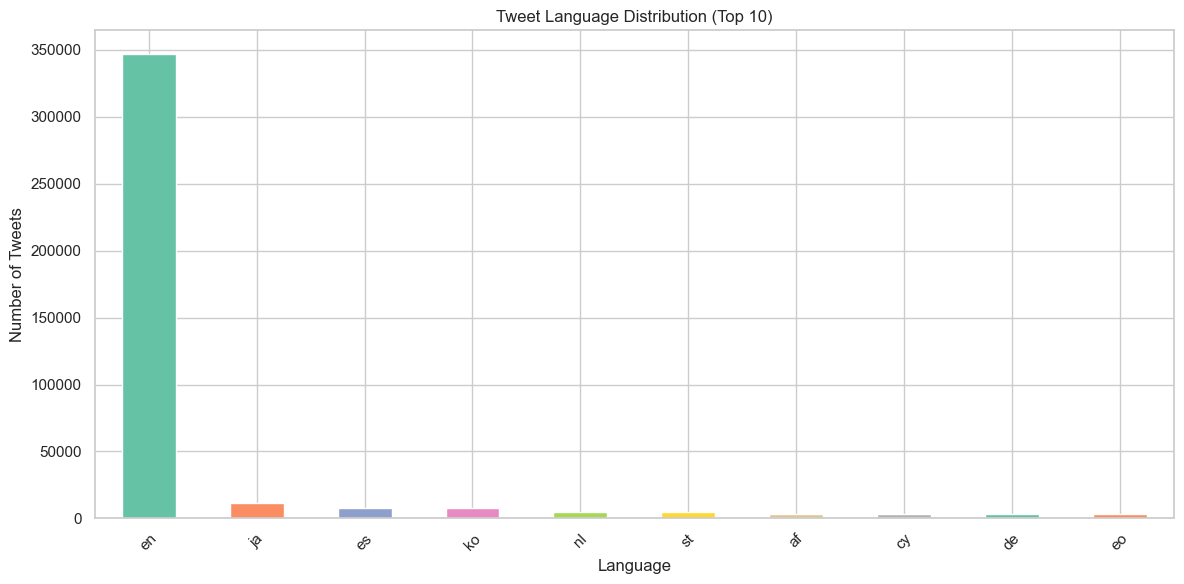


English tweets: 347,225 (79.5%)
Non-English tweets: 89,363 (20.5%)


In [17]:
from lingua import LanguageDetectorBuilder

# Build detector for all languages
detector = LanguageDetectorBuilder.from_all_languages().build()

def detect_lang(text):
    try:
        text = str(text).replace("\n", " ").strip()
        if not text or len(text) < 3:
            return "unknown"
        lang = detector.detect_language_of(text)
        return lang.iso_code_639_1.name.lower() if lang else "unknown"
    except:
        return "unknown"

tweets["language"] = tweets["body"].apply(detect_lang)

# Language breakdown
lang_counts = tweets["language"].value_counts()
total = len(tweets)

print(f"Languages detected: {len(lang_counts)}")
print(f"\nTop 10 languages:")
lang_df = pd.DataFrame({
    "Count": lang_counts,
    "%": (lang_counts / total * 100).round(2)
})
display(lang_df.head(10))

# Plot top 10 languages
fig, ax = plt.subplots(figsize=(12, 6))
lang_counts.head(10).plot(kind="bar", ax=ax, color=sns.color_palette("Set2", 10))
ax.set_xlabel("Language")
ax.set_ylabel("Number of Tweets")
ax.set_title("Tweet Language Distribution (Top 10)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_language.png", dpi=200, bbox_inches="tight")
plt.show()

# English vs non-English
en_count = lang_counts.get("en", 0)
non_en = total - en_count
print(f"\nEnglish tweets: {en_count:,} ({en_count/total*100:.1f}%)")
print(f"Non-English tweets: {non_en:,} ({non_en/total*100:.1f}%)")

## 8.6 Link / URL Analysis

Count how many tweets contain hyperlinks, extract every URL, and classify
them by domain type (e.g. link-shortener, financial-data, news, social media, image, other).

Tweets with at least one URL: 122 / 436,588 (0.03%)
Tweets without any URL:       436,466 / 436,588 (99.97%)
Total URL occurrences:        140
Avg URLs per tweet (overall): 0.0003
Avg URLs per tweet (with URL): 1.15


,Link Type,Count,% of All URLs
0,Other,69,49.3%
1,Link Shortener,49,35.0%
2,Financial / Trading,11,7.9%
3,Image / Media File,6,4.3%
4,Malformed / Artefact,3,2.1%
5,News / Media,2,1.4%


,Domain,Count,Category
0,amz,67,Other
1,buff.ly,49,Link Shortener
2,aotetf.com,4,Financial / Trading
3,tickeron.com,3,Financial / Trading
4,tech_brand_value.jpg,2,Image / Media File
5,tradershub.ninja,2,Financial / Trading
6,$1%2520trial%2520link%2520%e2%86%92%,1,Malformed / Artefact
7,join%2520for%2520$1%2520%e2%86%92%,1,Malformed / Artefact
8,momentum_sp500.jpg,1,Image / Media File
9,nvda_vs_amd.jpg,1,Image / Media File


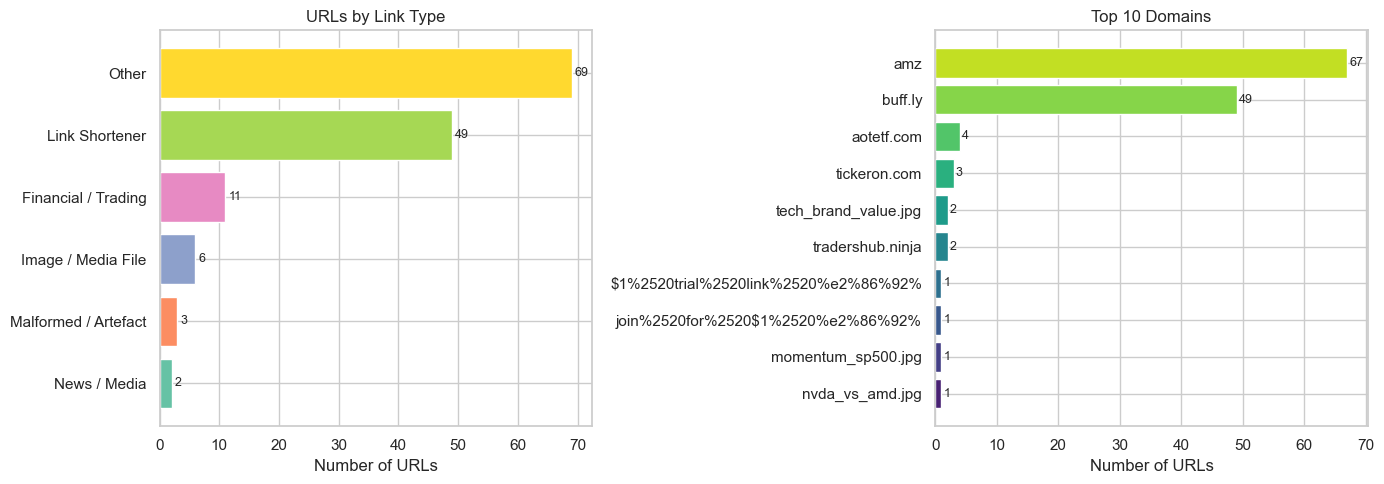


Sample tweets containing URLs (5 shown):

  [AAPL] ['https://buff.ly/3WGTrpL']
    Apple will reportedly release artificial intelligence features in October, weeks after iOS 18 update $AAPL #chatgpt #openai #artificialintelligence #generativeai #apple #iphone #ioshttps://buff.ly/3WG

  [AAPL] ['https://tickeron.com/trading-investing-101/momentum-stock-trading-powered-by-tickeron-ai/']
    Momentum Stock Trading Powered by Tickeron AIhttps://tickeron.com/trading-investing-101/momentum-stock-trading-powered-by-tickeron-ai/ $NVDA $MSFT $AAPL $AMZN $GOOG $GOOGL $META $AVGO $TSM $LLY $WMT $

  [AAPL] ['http://$1%2520trial%2520link%2520%E2%86%92%']
    Leaders: Double‑ticker heat: $AAPL & $MSFT. Trend or fade?. $1 gets you in — watchlists + alerts http://$1%2520trial%2520link%2520%E2%86%92% 2520tinyurl.com/TTN1DOLLAR

  [AAPL] ['http://Join%2520for%2520$1%2520%E2%86%92%']
    Theme: AI/datacenter core: $TSLA $NVDA $AAPL. Pullback playbook + live tape. $1 http://Join%2520for%2520$1%2520%E2%8

In [18]:
import re
from urllib.parse import urlparse
from collections import Counter

# Extract URLs from tweet bodies 
url_pattern = re.compile(r'https?://\S+')
tweets["urls"] = tweets["body"].astype(str).str.findall(url_pattern)
tweets["has_url"] = tweets["urls"].str.len() > 0
tweets["url_count"] = tweets["urls"].str.len()

total = len(tweets)
with_urls = tweets["has_url"].sum()
total_urls = tweets["url_count"].sum()

print(f"Tweets with at least one URL: {with_urls:,} / {total:,} ({with_urls/total*100:.2f}%)")
print(f"Tweets without any URL:       {total - with_urls:,} / {total:,} ({(total-with_urls)/total*100:.2f}%)")
print(f"Total URL occurrences:        {total_urls:,}")
print(f"Avg URLs per tweet (overall): {total_urls/total:.4f}")
if with_urls > 0:
    print(f"Avg URLs per tweet (with URL): {total_urls/with_urls:.2f}")

# Parse domains
flat_urls = [u for urls in tweets["urls"] for u in urls]

domain_list = []
for u in flat_urls:
    try:
        # Clean trailing punctuation that may be captured
        u_clean = re.sub(r'[),;:\'"!?\]>]+$', '', u)
        d = urlparse(u_clean).netloc.lower().replace("www.", "")
        if d:
            domain_list.append(d)
        else:
            domain_list.append("[no-domain]")
    except Exception:
        domain_list.append("[parse-error]")

domain_counts = Counter(domain_list)

# Classify link types 
LINK_CATEGORIES = {
    "Link Shortener": ["buff.ly", "bit.ly", "t.co", "tinyurl.com", "ow.ly",
                       "goo.gl", "is.gd", "shorturl.at", "rb.gy", "cutt.ly"],
    "Financial / Trading": ["tickeron.com", "tickeron.coma", "tradershub.ninja",
                            "aotetf.com", "tradingwiser.com", "finance.yahoo.com",
                            "stocktwits.com", "investing.com", "seekingalpha.com",
                            "benzinga.com", "marketwatch.com"],
    "News / Media": ["reuters.com", "cnbc.com", "bloomberg.com", "wsj.com",
                     "nytimes.com", "bbc.com", "nejm.org",
                     "michaelparekh.substack.com", "substack.com"],
    "Social Media": ["twitter.com", "x.com", "reddit.com", "youtube.com",
                     "youtu.be", "instagram.com", "facebook.com", "tiktok.com",
                     "linkedin.com", "threads.net", "discord.gg", "discord.com"],
    "Image / Media File": [],  # holds .jpg/.png/.gif domains below
}

def classify_domain(domain):
    for cat, domains in LINK_CATEGORIES.items():
        if domain in domains:
            return cat
    # Check if domain looks like an image filename (scraping artefact)
    if re.search(r'\.(jpg|jpeg|png|gif|webp|svg|bmp)$', domain):
        return "Image / Media File"
    # Check for percent-encoded / malformed domains (scraping artefact)
    if "%" in domain or domain.startswith("["):
        return "Malformed / Artefact"
    return "Other"

category_counts = Counter()
domain_to_cat = {}
for domain, count in domain_counts.items():
    cat = classify_domain(domain)
    category_counts[cat] += count
    domain_to_cat[domain] = cat

# Display results
cat_df = pd.DataFrame(
    [(cat, cnt, f"{cnt/total_urls*100:.1f}%") for cat, cnt in category_counts.most_common()],
    columns=["Link Type", "Count", "% of All URLs"]
)
display(cat_df)

dom_df = pd.DataFrame(
    [(d, c, domain_to_cat[d]) for d, c in domain_counts.most_common()],
    columns=["Domain", "Count", "Category"]
)
display(dom_df)

# Bar chart: link type breakdown 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: link type categories
cats = category_counts.most_common()
ax = axes[0]
ax.barh([c[0] for c in cats][::-1], [c[1] for c in cats][::-1],
        color=sns.color_palette("Set2", len(cats)))
for i, (cat, cnt) in enumerate(reversed(cats)):
    ax.text(cnt + 0.5, i, str(cnt), va="center", fontsize=9)
ax.set_xlabel("Number of URLs")
ax.set_title("URLs by Link Type")

# Right: top domains
top_doms = domain_counts.most_common(10)
ax = axes[1]
ax.barh([d[0] for d in top_doms][::-1], [d[1] for d in top_doms][::-1],
        color=sns.color_palette("viridis", len(top_doms)))
for i, (dom, cnt) in enumerate(reversed(top_doms)):
    ax.text(cnt + 0.3, i, str(cnt), va="center", fontsize=9)
ax.set_xlabel("Number of URLs")
ax.set_title("Top 10 Domains")

plt.tight_layout()
fig.savefig(BASE_DIR / "Report" / "eda_tweets_link_types.png", dpi=200, bbox_inches="tight")
plt.show()

# Sample tweets containing links
print(f"\nSample tweets containing URLs ({min(5, with_urls)} shown):")
url_tweets = tweets[tweets["has_url"]].head(5)
for _, row in url_tweets.iterrows():
    print(f"\n  [{row['ticker']}] {row['urls']}")
    print(f"    {str(row['body'])[:200]}")

## 9. Engagement vs Tweet Length Correlation

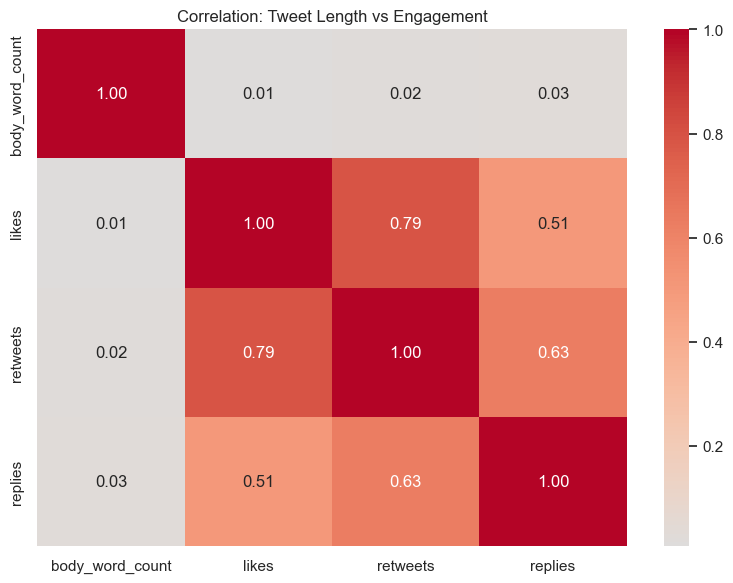

In [19]:
# Correlation between length and engagement
corr_cols = ["body_word_count", "likes", "retweets", "replies"]
corr_matrix = tweets[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Correlation: Tweet Length vs Engagement")
plt.tight_layout()
plt.show()

## 10. Summary

In [20]:
print("TWEETS DATASET EDA SUMMARY")
print(f"Total tweets:            {len(tweets):,}")
print(f"Tickers:                 {tweets['ticker'].nunique()}")
print(f"Date range:              {tweets['post_date'].min().strftime('%Y-%m-%d')} to {tweets['post_date'].max().strftime('%Y-%m-%d')}")
print(f"Missing bodies:          {tweets['body'].isna().sum():,}")
# Exclude list-typed columns (urls) that cannot be hashed
_dup_cols = [c for c in tweets.columns if tweets[c].dtype != object or not tweets[c].apply(type).eq(list).any()]
print(f"Duplicate rows:          {tweets.duplicated(subset=_dup_cols).sum():,}")
print(f"Avg tweet length:        {tweets['body_len'].mean():.0f} chars / {tweets['body_word_count'].mean():.0f} words")
print(f"Avg tweets per day:      {daily_counts.mean():.1f}")
print(f"\nEngagement metrics:")
print(f"Total likes:           {tweets['likes'].sum():,}")
print(f"Total retweets:        {tweets['retweets'].sum():,}")
print(f"Total replies:         {tweets['replies'].sum():,}")
print(f"Avg likes/tweet:       {tweets['likes'].mean():.1f}")
print(f"Avg retweets/tweet:    {tweets['retweets'].mean():.1f}")

TWEETS DATASET EDA SUMMARY
Total tweets:            436,588
Tickers:                 20
Date range:              2023-10-10 to 2026-02-11
Missing bodies:          0
Duplicate rows:          0
Avg tweet length:        144 chars / 24 words
Avg tweets per day:      535.0

Engagement metrics:
Total likes:           18,539,731.0
Total retweets:        2,237,244
Total replies:         1,730,949
Avg likes/tweet:       42.5
Avg retweets/tweet:    5.1
